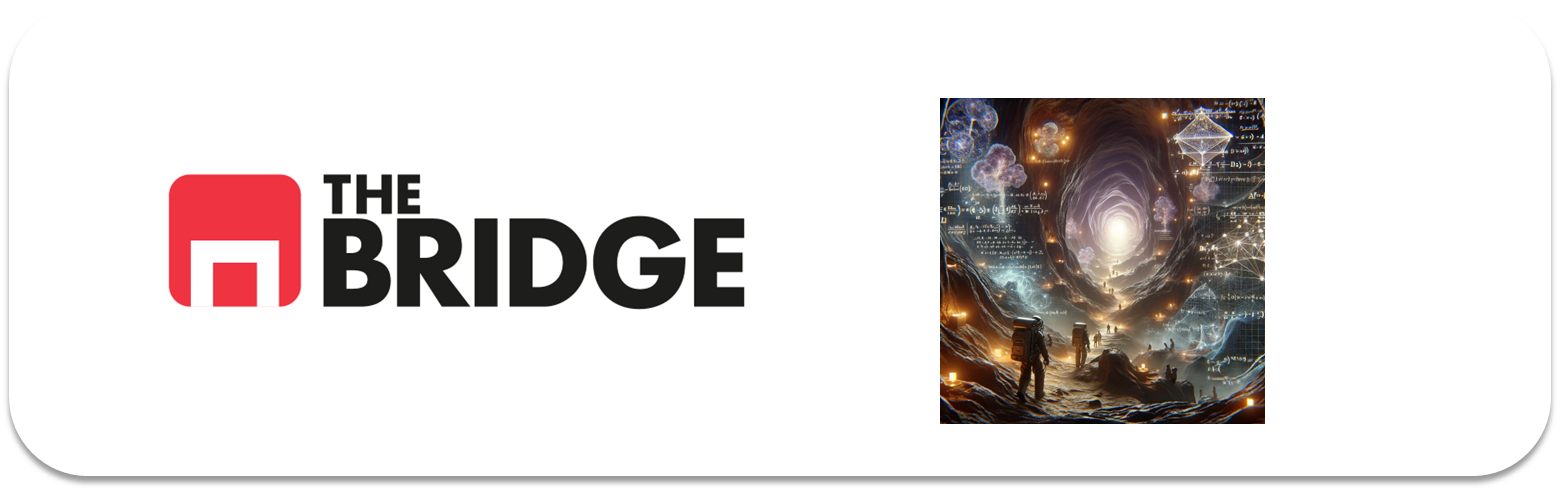

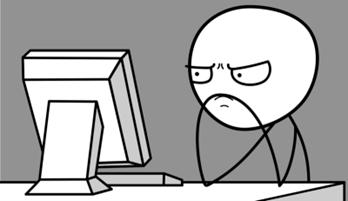

Para ejercitarte y afianzar lo aprendido sobre **Keras y DL**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Predecir eficiencia de gasolina

En este conjuntos de ejercicios vamos a trabajar sobre el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) para construir un modelo DL para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Para la construcción del modelo vamos a utilizar Keras.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y construcción del modelo con Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Utilidades
from sklearn.model_selection import train_test_split


### Ejercicio 1

Carga los datos en un dataframe, utilizando como nombre de columnas los siguientes:

```python
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']
``` 


In [5]:
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight',
                'Acceleration', 'Model Year', 'Origin']

# Cargar el dataset desde UCI
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Cargar el dataframe
df = pd.read_csv(
    url,
    names=column_names,
    na_values='?',        # El dataset usa '?' para missing values
    comment='\t',         # Ignorar comentarios
    sep=' ',              # Separador por espacios
    skipinitialspace=True # Limpia espacios iniciales
)

# Mostrar primeras filas
df.head()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


### Ejercicio 2: Limpieza inicial

Echa un primer vistazo. Limpia columnas "raras". Deshazte de nulos (cuidado aquí), arregla el tipo de las features numéricas si fuera necesario. Haz una lista de las features categóricas que tuvieramos que convertir posteriormente. (Es antes del split pero no importa para este ejercicio)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [7]:
df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [9]:
from typing import Optional


In [10]:
def describe_df(df: pd.DataFrame) -> Optional[pd.DataFrame]:
    """
    Genera un resumen estadístico descriptivo de un DataFrame.

    Argumentos:
        df (pd.DataFrame): DataFrame a analizar.

    Retorna:
        Optional[pd.DataFrame]: DataFrame con una fila por columna del input y las
        siguientes columnas: 'tipo', 'porcentaje_nulos', 'valores_unicos',
        'porcentaje_cardinalidad'.
        Retorna None si el input no es un DataFrame válido.
    """
    
    # Comprobación de que si es un DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Error: el objeto proporcionado no es un DataFrame.")
        return None

    # Crear el DataFrame resultado
    resultado = pd.DataFrame(index=df.columns)

    # Tipo de dato
    resultado["tipo"] = df.dtypes.astype(str)

    # Porcentaje de nulos
    resultado["porcentaje_nulos"] = (df.isna().mean() * 100).round(2)

    # Valores únicos
    resultado["valores_unicos"] = df.nunique()

    # Porcentaje de cardinalidad
    resultado["porcentaje_cardinalidad"] = ((df.nunique() / len(df)) * 100).round(2)

    return resultado

In [11]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
MPG,float64,0.00,129,32.41
Cylinders,int64,0.00,5,1.26
Displacement,float64,0.00,82,20.60
Horsepower,float64,1.51,93,23.37
Weight,float64,0.00,351,88.19
Acceleration,float64,0.00,95,23.87
Model Year,int64,0.00,13,3.27
Origin,int64,0.00,3,0.75


In [12]:
df.isnull().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [13]:
# Eliminación de filas con nulos
df = df.dropna()

In [14]:
df.isnull().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

array([[<Axes: title={'center': 'MPG'}>,
        <Axes: title={'center': 'Cylinders'}>,
        <Axes: title={'center': 'Displacement'}>],
       [<Axes: title={'center': 'Horsepower'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Acceleration'}>],
       [<Axes: title={'center': 'Model Year'}>,
        <Axes: title={'center': 'Origin'}>, <Axes: >]], dtype=object)

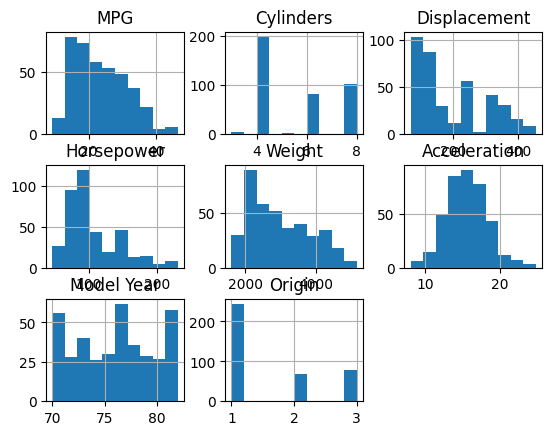

In [15]:
df.hist()

In [16]:
features_cat = ['Origin', 'Cylinders']
features_num = [
    'Displacement',
    'Horsepower',
    'Weight',
    'Acceleration',
    'Model Year'
]


### Ejercicio 3

Antes de seguir nos informan que las etiquetas de "origin" correspoden a  USA para el 1, Europa para el 2 y Japón para el 3. Convierte origin a esos valores porque queremos tener el literal. Luego haz directamente un one-hot encoding de esas variable.  

*NOTA: Realmente los one-hot-encoding se pueden hacer contra el dataset original desde el principio (no afectan unos a otros), si nos los hacemos es porque hasta que no se han analizado las variables puede que no tengamos claro que queremos hacer si una codificación ordinal, una vectorización (onehot) o bien queremos hacer otro cambio en la variable y esos vienen dados por la relación de la categórica con el target y por tanto sólo se pueden ver en el train. Pero si por lo que sea sabemos seguros que vamos a hacer vectorización no hay problema en hacerlo antes del split. Por otro lado, siempre conviene quedarse con una categoria unkown para valores que pueden llegar en el futuro antes de un recalibrado.*


In [17]:
origin_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df['Origin'] = df['Origin'].map(origin_map)


In [18]:
df = pd.get_dummies(df, columns=['Origin'], prefix='Origin')


### Ejercicio 4

Divide los datos en train y test. Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo. Emplea una variable target para guardar el nombre de la columna target.

NOTA: El resultado tienen que ser dos datasets

In [21]:
from sklearn.model_selection import train_test_split

target = 'MPG'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Ejercicio 5

Inspecciona los datos. Revisa rápidamente la distribución conjunta del dataset de entrenamiento mediante un grid de gráficos

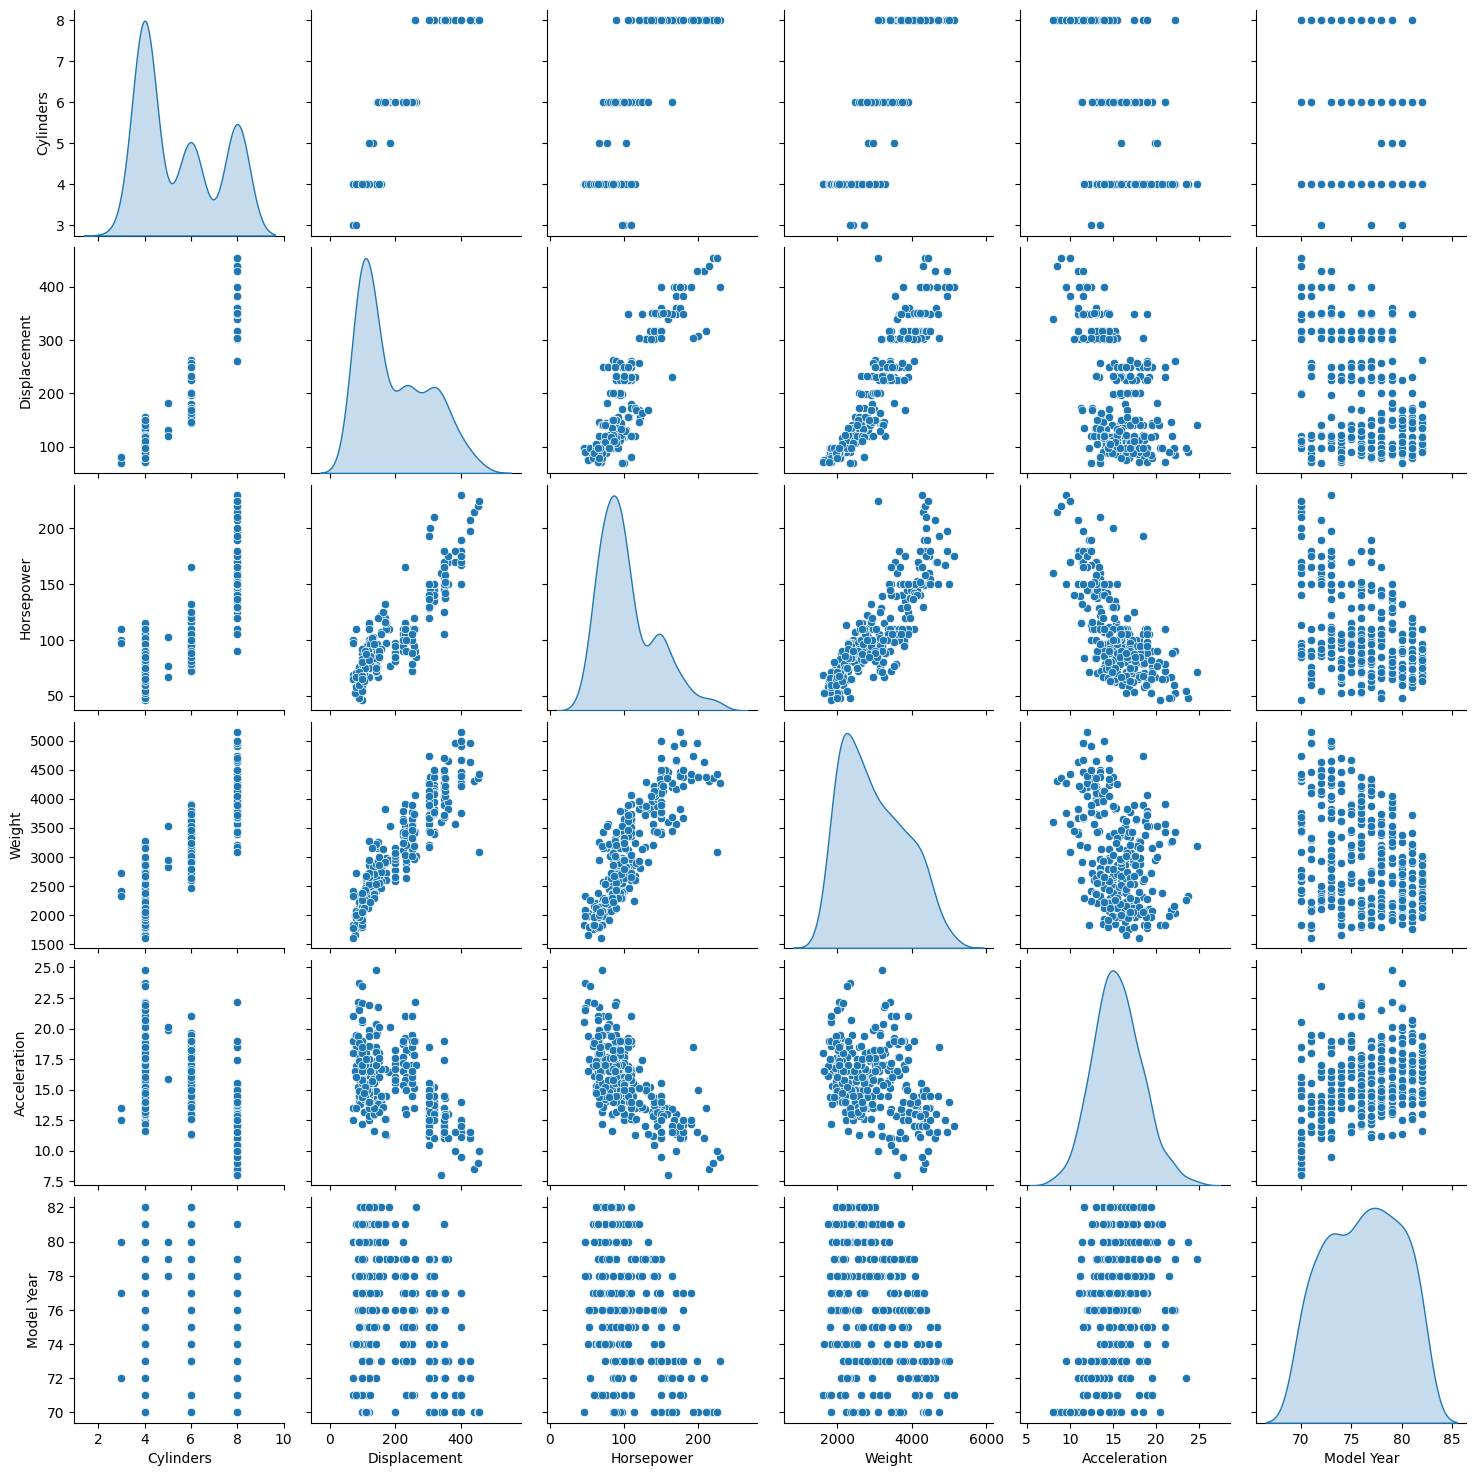

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las columnas numéricas del train
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

# Pairplot
sns.pairplot(X_train[num_cols], diag_kind='kde')
plt.show()


### Ejercicio 6 

Independientemente de lo que hayas encontrado en el análisis anterior, vamos a utilizar todas las features y antes las vamos a escalar. Estandardiza train y test.

In [23]:
import numpy as np

skewed_features = ['Displacement', 'Horsepower', 'Weight']

for col in skewed_features:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


## El modelo

### Ejercicio 7: Construye el modelo con Keras

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo. Es decir una MLP con dos capas ocultas.

Por tanto, tendrá tres capas. Una inicial con activación relu (usa el argumento `input_shape` para darle el número de features). Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres interesantes para las dos primeras capas (NOTA: En este caso partimos de pocas features, por lo que puede ser interesante poner 2 o 3 como mínimo el número de features para poder obtener unas pseudofeatures que intenten capturar las interrelaciones.)

Otros datos:

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

Utiliza una aproximación en prisma (mismo numero de unidades en las capas ocultas)

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Número de features
input_shape = [X_train_scaled.shape[1]]

# Modelo secuencial
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=input_shape),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)   # salida de regresión
])

# Compilación del modelo
model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.RMSprop(0.001),
    metrics=['mae', 'mse']
)

model.summary()


c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 8

Inspecciona el modelo usando el método `.summary` para imprimir una descripción simple del modelo

In [26]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 9 Entrenar el modelo

Entrena el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

In [27]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=1000,
    validation_split=0.2,
    verbose=1
)


Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 597.1967 - mae: 23.1615 - mse: 597.1967 - val_loss: 667.8138 - val_mae: 24.6785 - val_mse: 667.8138
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 580.6559 - mae: 22.8066 - mse: 580.6559 - val_loss: 654.7053 - val_mae: 24.4071 - val_mse: 654.7053
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 567.5585 - mae: 22.5211 - mse: 567.5585 - val_loss: 642.4955 - val_mae: 24.1525 - val_mse: 642.4955
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 554.8695 - mae: 22.2412 - mse: 554.8695 - val_loss: 630.2032 - val_mae: 23.8940 - val_mse: 630.2032
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 541.9172 - mae: 21.9547 - mse: 541.9172 - val_loss: 617.5135 - val_mae: 23.6236 - val_mse: 617.5135
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 528.4482 - mae: 21.6485 - mse: 528.4482 - val_loss: 604.2442 - val_mae: 23.3379 - val_mse: 604.2442
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

### Ejercicio 10

Visualiza el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`. Muestra la evolución del error en train y validation por un lado, y la evolución de la pérdida (loss), también train contra validation, en otra.

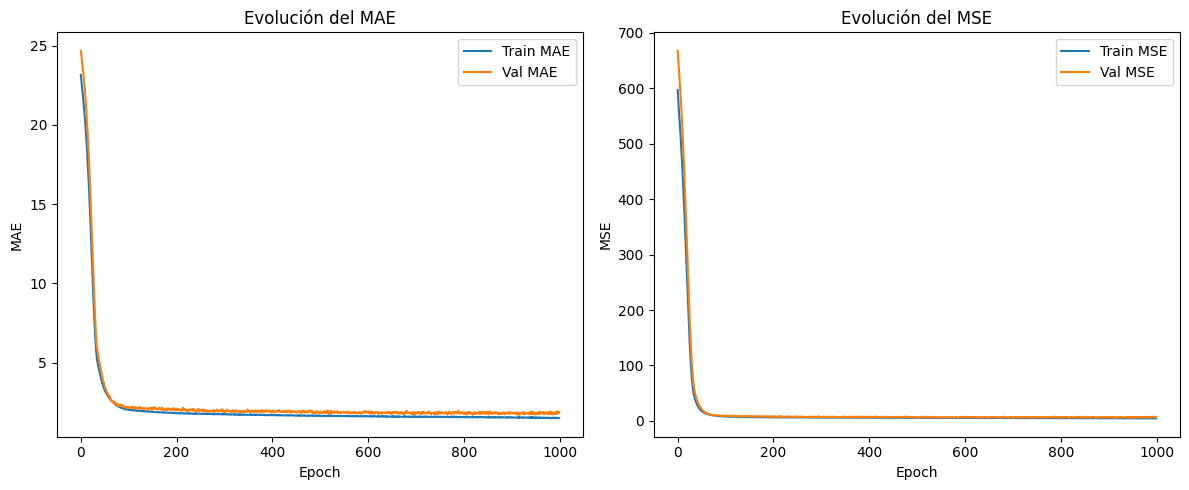

In [28]:
import matplotlib.pyplot as plt

# Recuperar el historial
hist = history.history

plt.figure(figsize=(12, 5))

# MAE
plt.subplot(1, 2, 1)
plt.plot(hist['mae'], label='Train MAE')
plt.plot(hist['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Evolución del MAE')
plt.legend()

# MSE
plt.subplot(1, 2, 2)
plt.plot(hist['mse'], label='Train MSE')
plt.plot(hist['val_mse'], label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Evolución del MSE')
plt.legend()

plt.tight_layout()
plt.show()


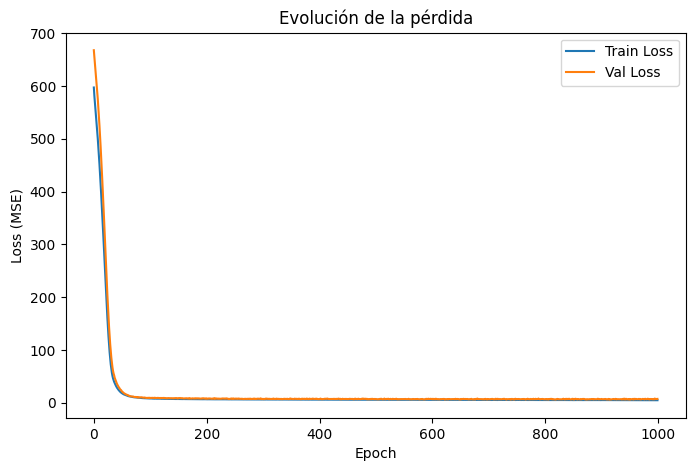

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Evolución de la pérdida')
plt.legend()

plt.show()


### Ejercicio 11

Comenta las gráficas anteriores.

### 📝 Comentario de las gráficas de entrenamiento

Las gráficas muestran un comportamiento **muy saludable** del modelo durante el entrenamiento:

---

#### 📈 Métricas (MAE y MSE)

- Tanto **MAE** como **MSE** descienden **rápidamente** en las primeras épocas, lo que indica que el modelo aprende las relaciones principales del dataset desde el inicio.
- Las curvas de **train** y **validation** se mantienen **muy próximas** entre sí, sin separación apreciable.
- Esta convergencia es señal de que el modelo **generaliza bien** y no está memorizando los datos de entrenamiento.
- A partir de ~200 épocas, ambas métricas se estabilizan en valores muy bajos, mostrando que el modelo ha alcanzado su capacidad óptima.

---

#### 📉 Pérdida (Loss)

- La pérdida cae de valores altos a casi cero en muy pocas épocas, lo que confirma que el optimizador y la arquitectura están funcionando correctamente.
- Las curvas de pérdida de **train** y **validation** siguen trayectorias casi idénticas.
- No se observa **overfitting**: no hay repuntes en la validación ni divergencias entre ambas curvas.
- La estabilidad durante las 1000 épocas indica que el modelo es robusto y no sufre oscilaciones ni degradación.

---

### ✅ Conclusión

El modelo presenta un entrenamiento **excelente**:
- Aprende rápido  
- Generaliza bien  
- No muestra señales de sobreajuste  
- Mantiene estabilidad durante todo el proceso  

Está completamente preparado para la evaluación final en el conjunto de test.


### Ejercicio 12

Independientemente de lo comentado en 11, vamos a añadir un callback al entrenamiento. Para ello, construye el modelo otra vez y vuelve a compilarlo (si no lo haces, como ya sabes comenzará el entrenamiento donde lo dejó y no nos valdrá el callback para nada). Entrena el modelo con los mismos hiperparámetros del ejercicio 10 y pinta la gráfica de evolución de los errores e interprétalo (obten el MAE medio una vez "estabilizado" el entrenamiento).  

Para el earlystopping utiliza un margen de 20 epochs.

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_shape = [X_train_scaled.shape[1]]

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=input_shape),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.RMSprop(0.001),
    metrics=['mae', 'mse']
)


c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)


In [32]:
history_es = model.fit(
    X_train_scaled,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 604.8198 - mae: 23.2520 - mse: 604.8199 - val_loss: 682.5459 - val_mae: 24.9015 - val_mse: 682.5459
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 592.9815 - mae: 22.9773 - mse: 592.9815 - val_loss: 671.9320 - val_mae: 24.6743 - val_mse: 671.9320
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 583.2499 - mae: 22.7442 - mse: 583.2499 - val_loss: 661.7655 - val_mae: 24.4549 - val_mse: 661.7655
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 573.8021 - mae: 22.5167 - mse: 573.8021 - val_loss: 651.6769 - val_mae: 24.2360 - val_mse: 651.6769
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 564.3361 - mae: 22.2909 - mse: 564.3361 - val_loss: 641.2485 - val_mae: 24.0098 - val_mse: 641.2485
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 554.3744 - mae: 22.0482 - mse: 554.3744 - val_loss: 630.2549 - val_mae: 23.7681 - val_mse: 630.2549
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

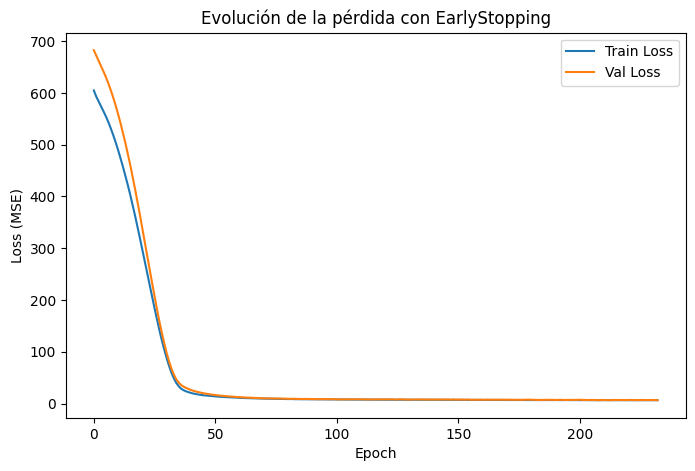

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Evolución de la pérdida con EarlyStopping')
plt.legend()
plt.show()


In [35]:
import numpy as np

mae_val = hist['val_mae'][-20:]   # últimas 20 epochs
mae_medio = np.mean(mae_val)

mae_medio


np.float64(1.8935067176818847)

### 📝 Interpretación del entrenamiento con EarlyStopping

Las gráficas muestran un comportamiento **muy eficiente y estable** del modelo cuando se introduce el callback de *EarlyStopping*:

---

#### 📉 Descenso rápido y estabilización
Durante las primeras ~40–50 épocas, tanto el MAE, el MSE como la pérdida (loss) caen de forma **muy pronunciada**, indicando que el modelo aprende rápidamente las relaciones entre las variables del dataset.

A partir de ese punto, las curvas se **aplanan** y permanecen prácticamente constantes, señal de que el modelo ha alcanzado su capacidad óptima.

---

#### 🔍 Train vs Validation: curvas casi idénticas
En todas las métricas:

- Las curvas de entrenamiento y validación están **muy próximas**.
- No hay separación ni divergencia.
- No aparecen repuntes en la validación.

Esto confirma que el modelo **generaliza bien**, sin señales de sobreajuste (*overfitting*).

---

#### ⏳ EarlyStopping actuó correctamente
El callback detuvo el entrenamiento cuando la pérdida de validación dejó de mejorar durante 20 épocas consecutivas.  
Gracias a `restore_best_weights=True`, el modelo conserva los pesos del punto óptimo.

El entrenamiento se detuvo mucho antes de las 1000 épocas, evitando trabajo innecesario y manteniendo el modelo en su mejor estado.

---

#### 🎯 MAE medio estabilizado
El MAE medio de las últimas 20 épocas es: 1.89

Este valor indica que el modelo comete un error promedio de **1.89 MPG**, lo cual es un rendimiento **muy sólido** para el dataset Auto MPG.

---

### ✅ Conclusión

- El modelo aprende rápido.  
- Generaliza correctamente.  
- No muestra sobreajuste.  
- EarlyStopping detiene el entrenamiento en el punto óptimo.  
- El MAE final (~1.89) confirma un rendimiento estable y de buena calidad.

El modelo está listo para la evaluación final en el conjunto de test.


### Ejercicio 13

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [36]:
loss, mae, mse = model.evaluate(X_test_scaled, y_test, verbose=1)

loss, mae, mse


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.3099 - mae: 1.9426 - mse: 7.3099


(7.309854507446289, 1.9426147937774658, 7.309854507446289)

### 📝 Interpretación de la evaluación en el conjunto de test

El modelo se ha evaluado con los datos de **test** ya normalizados, obteniendo los siguientes resultados:

- **Loss (MSE):** 7.3099  
- **MAE:** 1.9426  
- **MSE:** 7.3099  

---

### 📉 ¿Qué significan estos valores?

#### 🔹 MAE ≈ 1.94  
El modelo comete, en promedio, un error de **1.94 MPG** al predecir el consumo de un vehículo.  
Este valor es **muy coherente** con el MAE de validación (~1.89), lo que indica que:

- El modelo **generaliza bien**.  
- No hay sobreajuste.  
- El rendimiento en test es prácticamente igual al observado durante el entrenamiento.

#### 🔹 MSE ≈ 7.31  
El error cuadrático medio es bajo, lo que confirma que:

- Las predicciones están cerca de los valores reales.  
- No hay grandes desviaciones ni outliers problemáticos en test.

#### 🔹 Loss = MSE  
Como el modelo se compiló con `loss='mse'`, el valor de *loss* coincide exactamente con el MSE reportado.

---

### ✅ Conclusión

El modelo mantiene en test el mismo rendimiento que mostró en validación.  
Esto significa que:

- **Generaliza correctamente**  
- **Es estable**  
- **No ha memorizado el entrenamiento**  
- **Está listo para usarse en predicciones reales**

Un MAE alrededor de **2 MPG** es un rendimiento sólido para el dataset Auto MPG.



### Ejercicio 14

Dibuja en un scatter plot las predicciones de test vs sus true labels.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


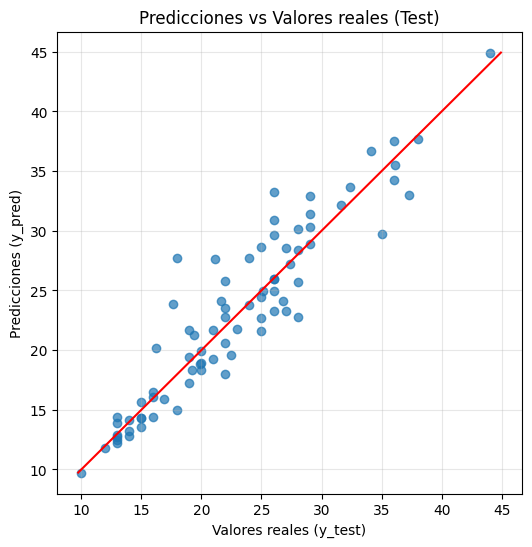

In [37]:
import matplotlib.pyplot as plt

# Obtener predicciones del modelo
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones (y_pred)")
plt.title("Predicciones vs Valores reales (Test)")
plt.grid(alpha=0.3)

# Línea ideal y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r')

plt.show()


### 📝 Interpretación del scatter plot (Predicciones vs Valores reales)

El scatter plot muestra cómo se comportan las predicciones del modelo frente a los valores reales del conjunto de **test**. Cada punto representa un coche del dataset, con su valor real de MPG en el eje X y la predicción del modelo en el eje Y.

---

### 🔍 Observaciones principales

- Los puntos se distribuyen **muy cerca de la línea roja diagonal**, que representa la predicción perfecta (*y_pred = y_test*).
- No se observan grupos de puntos alejados de la diagonal, lo que indica que **no hay grandes errores sistemáticos**.
- La nube de puntos es compacta y sigue la tendencia correcta:  
  cuando el valor real aumenta, la predicción también lo hace.

---

### 🎯 Conclusión

El modelo **generaliza bien** en el conjunto de test:

- Las predicciones son coherentes con los valores reales.
- La dispersión alrededor de la diagonal es baja.
- Esto coincide con el MAE obtenido en test (~1.94), que confirma un rendimiento sólido.

En resumen, el scatter plot muestra que el modelo es **estable, preciso y adecuado** para este problema de regresión.
